## Imports, paths and constants

In [10]:
conda install -c anaconda scikit-learn


2 channel Terms of Service accepted
Channels:
 - anaconda
 - defaults
Platform: osx-arm64
Solving environment: done

## Package Plan ##

  environment location: /Users/gayandesilva/miniconda3/envs/ai4beg

  added / updated specs:
    - scikit-learn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    joblib-1.5.3               |  py310hca03da5_0         407 KB  anaconda
    scikit-learn-1.7.2         |  py310h3f644e9_1         7.4 MB  anaconda
    scipy-1.15.3               |  py310he2f6300_2        19.2 MB  anaconda
    threadpoolctl-3.5.0        |  py310h7eb115d_1          42 KB  anaconda
    ------------------------------------------------------------
                                           Total:        27.1 MB

The following NEW packages will be INSTALLED:

  joblib             anaconda/osx-arm64::joblib-1.5.3-py310hca03da5_0 
  scikit-learn       anaconda/osx-arm64::scikit-learn-1.

In [11]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_PATH = ROOT / "data" / "raw" / "DataCoSupplyChainDataset.csv"
PROCESSED_DIR = ROOT / "data" / "processed"
REPORTS_DIR = ROOT / "reports"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "Days for shipping (real)"          # what we predict
SCHED = "Days for shipment (scheduled)"      # dropped: redundant with Shipping Mode (used only as evidence in Step 3)
LATE = "Late_delivery_risk"                  # dropped: derived from TARGET -> leakage
GROUP = "Order Id"
SEED = 42
print("Project root:", ROOT)

Project root: /Users/gayandesilva/Documents/Projects/dataco-late-delivery-predictor


## Load the raw data

#### Read the CSV

In [12]:
raw = pd.read_csv(RAW_PATH, encoding="latin-1")
raw.columns = raw.columns.str.strip()
print(f"Rows: {raw.shape[0]:,}   Columns: {raw.shape[1]}   Unique orders: {raw[GROUP].nunique():,}")

Rows: 180,519   Columns: 53   Unique orders: 65,752


#### Encoding check

In [13]:
accented = raw["Order Country"][raw["Order Country"].str.contains("[áéíóúñü]", regex=True, na=False)]
print(sorted(accented.unique())[:10])

['Afganistán', 'Arabia Saudí', 'Azerbaiyán', 'Bangladés', 'Baréin', 'Benín', 'Bután', 'Bélgica', 'Camerún', 'España']


## Structure and target distribution

#### Overview tabl

In [14]:
overview = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "n_unique": raw.nunique(),
    "missing_%": (raw.isna().mean() * 100).round(2),
}).sort_values(["missing_%", "n_unique"], ascending=[False, True])
overview

,dtype,n_unique,missing_%
Product Description,float64,0,100.00
Order Zipcode,float64,609,86.24
Customer Email,object,1,0.00
Customer Password,object,1,0.00
Product Status,int64,1,0.00
Late_delivery_risk,int64,2,0.00
Customer Country,object,2,0.00
Customer Segment,object,3,0.00
Type,object,4,0.00
Days for shipment (scheduled),int64,4,0.00


#### Target distribution

Distribution of real shipping days (% of rows):
Days for shipping (real)
0     2.8
1     2.6
2    31.4
3    15.9
4    15.8
5    15.6
6    15.9
Name: proportion, dtype: float64

Mean 3.50 | median 3 | std 1.62 | range 0-6


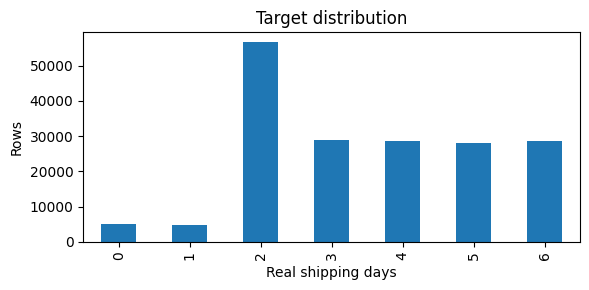

In [15]:
print("Distribution of real shipping days (% of rows):")
print(raw[TARGET].value_counts(normalize=True).sort_index().mul(100).round(1))
print(f"\nMean {raw[TARGET].mean():.2f} | median {raw[TARGET].median():.0f} | std {raw[TARGET].std():.2f} | range {raw[TARGET].min()}-{raw[TARGET].max()}")

fig, ax = plt.subplots(figsize=(6, 3))
raw[TARGET].value_counts().sort_index().plot.bar(ax=ax)
ax.set_xlabel("Real shipping days"); ax.set_ylabel("Rows"); ax.set_title("Target distribution")
plt.tight_layout(); plt.show()

#### Prove the leakage for this target

In [16]:
rule = (raw[TARGET] > raw[SCHED]).astype(int)
match_pct = (rule == raw[LATE]).mean() * 100
print(f"{LATE} == ({TARGET} > {SCHED}) for {match_pct:.1f}% of rows")
print("\nRows breaking the rule, by Delivery Status:")
print(raw.loc[rule != raw[LATE], "Delivery Status"].value_counts())

Late_delivery_risk == (Days for shipping (real) > Days for shipment (scheduled)) for 97.5% of rows

Rows breaking the rule, by Delivery Status:
Delivery Status
Shipping canceled    4423
Name: count, dtype: int64


#### Delivery Status encodes real vs scheduled days

In [17]:
gap = raw[TARGET] - raw[SCHED]
pd.crosstab(raw["Delivery Status"], np.sign(gap).map({-1: "real < scheduled", 0: "real = scheduled", 1: "real > scheduled"}))

col_0,real < scheduled,real = scheduled,real > scheduled
Delivery Status,,,
Advance shipping,41592,0,0
Late delivery,0,0,98977
Shipping canceled,1774,1557,4423
Shipping on time,0,32196,0


#### Shipping date = order date + target

In [18]:
DATE_FMT = "%m/%d/%Y %H:%M"
order_dt = pd.to_datetime(raw["order date (DateOrders)"], format=DATE_FMT)
ship_dt = pd.to_datetime(raw["shipping date (DateOrders)"], format=DATE_FMT)
gap_days = (ship_dt - order_dt).dt.days
print(f"(shipping date - order date) in whole days == {TARGET} for {(gap_days == raw[TARGET]).mean() * 100:.1f}% of rows")

(shipping date - order date) in whole days == Days for shipping (real) for 97.4% of rows


#### Order Status is recorded after fulfilment

In [19]:
pd.crosstab(raw["Order Status"], raw["Delivery Status"])

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Order Status,,,,
CANCELED,0,0,3692,0
CLOSED,4809,11109,0,3698
COMPLETE,14136,34199,0,11156
ON_HOLD,2413,5450,0,1941
PAYMENT_REVIEW,420,1082,0,391
PENDING,4857,11712,0,3658
PENDING_PAYMENT,9588,22922,0,7322
PROCESSING,5369,12503,0,4030
SUSPECTED_FRAUD,0,0,4062,0


#### Profit columns vs the target

In [20]:
# Do the profit columns change with the real shipping days? A strong trend would suggest they include shipping costs.
shipped = raw[~raw["Order Status"].isin(["CANCELED", "SUSPECTED_FRAUD"])]
shipped.groupby(TARGET)[["Benefit per order", "Order Item Profit Ratio"]].mean().round(3)

,Benefit per order,Order Item Profit Ratio
Days for shipping (real),,
0,22.710,0.123
1,18.924,0.111
2,23.292,0.126
3,21.453,0.117
4,22.231,0.123
5,21.186,0.116
6,21.147,0.118


## Order-level structure

In [21]:
per_order = raw.groupby(GROUP).agg(
    items=(TARGET, "size"),
    n_target=(TARGET, "nunique"),
    n_status=("Order Status", "nunique"),
    n_mode=("Shipping Mode", "nunique"),
    n_city=("Order City", "nunique"),
)
print("Items per order:\n", per_order["items"].describe().round(2), "\n")
print(f"Orders with more than one item: {(per_order['items'] > 1).mean() * 100:.1f}%")
print(f"Orders whose items have different real shipping days: {(per_order['n_target'] > 1).sum()}")
print(f"Orders whose items have different Order Status:       {(per_order['n_status'] > 1).sum()}")
print(f"Orders whose items have different Shipping Mode:      {(per_order['n_mode'] > 1).sum()}")
print(f"Orders whose items have different Order City:         {(per_order['n_city'] > 1).sum()}")

Items per order:
 count    65752.00
mean         2.75
std          1.48
min          1.00
25%          1.00
50%          3.00
75%          4.00
max          5.00
Name: items, dtype: float64 

Orders with more than one item: 69.8%
Orders whose items have different real shipping days: 0
Orders whose items have different Order Status:       0
Orders whose items have different Shipping Mode:      0
Orders whose items have different Order City:         0


## Remove cancelled and suspected-fraud orders

In [22]:
EXCLUDE_STATUS = ["CANCELED", "SUSPECTED_FRAUD"]
bad_orders = raw.loc[raw["Order Status"].isin(EXCLUDE_STATUS), GROUP].unique()
excluded = raw[raw[GROUP].isin(bad_orders)]

print(f"Rows removed:   {len(excluded):,}")
print(f"Orders removed: {len(bad_orders):,}")
print("\nDelivery Status of removed rows:\n", excluded["Delivery Status"].value_counts())
print(f"\nRemoved rows that still have a 'real shipping days' value: {excluded[TARGET].notna().sum():,}")

df = raw[~raw[GROUP].isin(bad_orders)].copy()
print(f"\nAfter filtering: {df.shape[0]:,} rows, {df[GROUP].nunique():,} orders")

Rows removed:   7,754
Orders removed: 2,855

Delivery Status of removed rows:
 Delivery Status
Shipping canceled    7754
Name: count, dtype: int64

Removed rows that still have a 'real shipping days' value: 7,754

After filtering: 172,765 rows, 62,897 orders


## Drop columns, each with a recorded reason

#### Detect exactly duplicated columns

In [23]:
def same_values(a, b):
    if pd.api.types.is_numeric_dtype(a) and pd.api.types.is_numeric_dtype(b):
        return np.allclose(a.to_numpy(float), b.to_numpy(float), equal_nan=True)
    return a.astype(str).equals(b.astype(str))

n_unique = df.nunique(dropna=False)
cols = list(df.columns)
dup_pairs = [
    (c1, c2)
    for i, c1 in enumerate(cols) for c2 in cols[i + 1:]
    if n_unique[c1] == n_unique[c2] and same_values(df[c1], df[c2])
]
for p in dup_pairs:
    print(" = ".join(p))

Benefit per order = Order Profit Per Order
Sales per customer = Order Item Total
Category Id = Product Category Id
Customer Email = Customer Password
Customer Id = Order Customer Id
Order Item Cardprod Id = Product Card Id
Order Item Product Price = Product Price


#### Check ID ↔ name pairs

In [24]:
def one_to_one(a, b):
    return df.groupby(a)[b].nunique().max() == 1 and df.groupby(b)[a].nunique().max() == 1

ID_NAME_PAIRS = [("Category Id", "Category Name"), ("Department Id", "Department Name"), ("Product Card Id", "Product Name")]
id_name_result = {f"{a} <-> {b}": one_to_one(a, b) for a, b in ID_NAME_PAIRS}
id_name_result

{'Category Id <-> Category Name': False,
 'Department Id <-> Department Name': True,
 'Product Card Id <-> Product Name': True}

#### Build the drop log

In [25]:
drop_log = []
PROTECTED = {TARGET, GROUP}   # target and grouping key are never dropped

def log_drop(columns, reason):
    for c in columns:
        if c in df.columns and c not in PROTECTED and c not in {d["column"] for d in drop_log}:
            drop_log.append({"column": c, "reason": reason})

# 1. Leakage for THIS task – derived from the target or recorded after fulfilment
log_drop([LATE], "Leakage: defined as real days > scheduled days")
log_drop(["Delivery Status"], "Leakage: text version of real vs scheduled days")
log_drop(["shipping date (DateOrders)"], "Leakage: order date + real shipping days")
log_drop(["Order Status"], "Leakage: recorded after fulfilment (used only to filter)")

# 1b. Redundant – known at order time, but fully determined by Shipping Mode
log_drop([SCHED], "Redundant: fully determined by Shipping Mode")

# 2. Personal / masked data
log_drop(["Customer Email", "Customer Password"], "Masked (all 'XXXXXXXXX'), no information")
log_drop(["Customer Fname", "Customer Lname", "Customer Street", "Customer Zipcode"], "Personal data (PII), no predictive meaning")

# 3. Empty, mostly missing or constant
for c in df.columns:
    miss = df[c].isna().mean() * 100
    if miss > 80:
        log_drop([c], f"{miss:.1f}% missing")
    elif df[c].nunique(dropna=True) <= 1:
        log_drop([c], "Constant: a single value in every row")
log_drop(["Product Image"], "Image URL: one per product, duplicates Product Name")

# 4. Exact duplicate columns
KEEP = {"Customer Id", "Product Card Id", "Category Id", "Benefit per order", "Sales per customer", "Product Price"}
for c1, c2 in dup_pairs:
    drop = c2 if c1 in KEEP or c2 not in KEEP else c1
    keep = c1 if drop == c2 else c2
    log_drop([drop], f"Exact duplicate of '{keep}'")

# 5. Code columns that are 1-to-1 with a readable name
for (a, b), ok in zip(ID_NAME_PAIRS, id_name_result.values()):
    if ok:
        log_drop([a], f"1-to-1 with '{b}' (same information as a code)")

# 6. Pure identifiers
log_drop(["Order Item Id"], "Row identifier")
log_drop(["Customer Id"], "Identifier: would let the model memorise customers")

drop_df = pd.DataFrame(drop_log)
drop_df

,column,reason
0,Late_delivery_risk,Leakage: defined as real days > scheduled days
1,Delivery Status,Leakage: text version of real vs scheduled days
2,shipping date (DateOrders),Leakage: order date + real shipping days
3,Order Status,Leakage: recorded after fulfilment (used only ...
4,Days for shipment (scheduled),Redundant: fully determined by Shipping Mode
5,Customer Email,"Masked (all 'XXXXXXXXX'), no information"
6,Customer Password,"Masked (all 'XXXXXXXXX'), no information"
7,Customer Fname,"Personal data (PII), no predictive meaning"
8,Customer Lname,"Personal data (PII), no predictive meaning"
9,Customer Street,"Personal data (PII), no predictive meaning"


#### Apply the drops and save the log

In [26]:
df_clean = df.drop(columns=drop_df["column"]).reset_index(drop=True)
drop_df.to_csv(REPORTS_DIR / "drop_log_m1_reg.csv", index=False)
print(f"Dropped {len(drop_df)} columns -> {df_clean.shape[1]} remain")
print(df_clean.columns.tolist())

Dropped 25 columns -> 28 remain
['Type', 'Days for shipping (real)', 'Benefit per order', 'Sales per customer', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Region', 'Order State', 'Product Name', 'Product Price', 'Shipping Mode']


## Final quality checks

#### Duplicates, missing values, final shape

In [27]:
print("Exact duplicate rows:", df_clean.duplicated().sum())
remaining_missing = df_clean.isna().sum()
print("Columns with missing values:\n", remaining_missing[remaining_missing > 0] if remaining_missing.any() else "none")
print(f"\nClean shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"Mean real shipping days after cleaning: {df_clean[TARGET].mean():.2f}")

Exact duplicate rows: 0
Columns with missing values:
 none

Clean shape: 172,765 rows x 28 columns
Mean real shipping days after cleaning: 3.50


## One shared train/test split, grouped by Order Id

#### Grouped, stratified split

In [28]:
# The target takes whole values 0-6, so it can be used directly as the stratification label
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, test_idx = next(sgkf.split(df_clean, df_clean[TARGET], groups=df_clean[GROUP]))
train = df_clean.iloc[train_idx].reset_index(drop=True)
test = df_clean.iloc[test_idx].reset_index(drop=True)

def summarise(name, d):
    return {"set": name, "rows": len(d), "orders": d[GROUP].nunique(),
            "share_of_rows_%": round(len(d) / len(df_clean) * 100, 1),
            "mean_days": round(d[TARGET].mean(), 3), "std_days": round(d[TARGET].std(), 3)}

split_summary = pd.DataFrame([summarise("full", df_clean), summarise("train", train), summarise("test", test)])
overlap = set(train[GROUP]) & set(test[GROUP])
print("Order Ids appearing in BOTH train and test:", len(overlap))
assert len(overlap) == 0, "Leak: an order is split across train and test"
split_summary

Order Ids appearing in BOTH train and test: 0


,set,rows,orders,share_of_rows_%,mean_days,std_days
0,full,172765,62897,100.0,3.499,1.623
1,train,138098,50318,79.9,3.500,1.626
2,test,34667,12579,20.1,3.494,1.614


#### Distribution chart

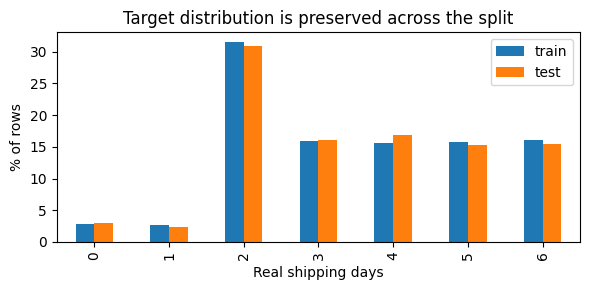

In [29]:
dist = pd.DataFrame({
    "train": train[TARGET].value_counts(normalize=True).sort_index() * 100,
    "test": test[TARGET].value_counts(normalize=True).sort_index() * 100,
})
ax = dist.plot.bar(figsize=(6, 3))
ax.set_xlabel("Real shipping days"); ax.set_ylabel("% of rows"); ax.set_title("Target distribution is preserved across the split")
plt.tight_layout(); plt.show()

## Save the shared files

#### Write the outputs

In [30]:
train.to_csv(PROCESSED_DIR / "train_reg.csv", index=False)
test.to_csv(PROCESSED_DIR / "test_reg.csv", index=False)

meta = {
    "task": "regression",
    "target": TARGET,
    "group": GROUP,
    "seed": SEED,
    "split": "StratifiedGroupKFold(n_splits=5) on the target, fold 0 = test",
    "excluded_order_status": EXCLUDE_STATUS,
    "dropped_columns": drop_df.to_dict(orient="records"),
    "feature_columns": [c for c in df_clean.columns if c not in (TARGET, GROUP)],
    "summary": split_summary.to_dict(orient="records"),
}
with open(PROCESSED_DIR / "split_meta_reg.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print("Saved:", *sorted(p.name for p in PROCESSED_DIR.iterdir() if "reg" in p.name), sep="\n  ")

Saved:
  split_meta_reg.json
  test_reg.csv
  train_reg.csv


## Pipeline skeleton and baselines

#### Feature groups

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

X_train = train.drop(columns=[TARGET])
y_train, groups_train = train[TARGET], train[GROUP]
DATE_COL = "order date (DateOrders)"

NUMERIC = [c for c in X_train.select_dtypes("number").columns if c != GROUP]
CATEGORICAL = [c for c in X_train.select_dtypes(exclude="number").columns if c != DATE_COL]
LOW_CARD = [c for c in CATEGORICAL if X_train[c].nunique() <= 30]
HIGH_CARD = [c for c in CATEGORICAL if c not in LOW_CARD]

print("Numeric:           ", NUMERIC)
print("Low-cardinality:   ", LOW_CARD)
print("High-cardinality:  ", {c: X_train[c].nunique() for c in HIGH_CARD})

Numeric:            ['Benefit per order', 'Sales per customer', 'Category Id', 'Latitude', 'Longitude', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Product Price']
Low-cardinality:    ['Type', 'Customer Country', 'Customer Segment', 'Department Name', 'Market', 'Order Region', 'Shipping Mode']
High-cardinality:   {'Category Name': 50, 'Customer City': 563, 'Customer State': 46, 'Order City': 3494, 'Order Country': 161, 'Order State': 1065, 'Product Name': 118}


#### build_pipeline() and baselines

In [32]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate

def build_pipeline(model):
    pre = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), NUMERIC),            # M4: scaling / outliers
            ("low_card", Pipeline([
                ("impute", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]), LOW_CARD),                                                  # M3
            # ("high_card", <M3 frequency/target encoder>, HIGH_CARD),     # M3 (target encoding = mean days)
            # ("date", <M2 date-feature transformer>, [DATE_COL]),          # M2
        ],
        remainder="drop",
    )
    return Pipeline([("prep", pre), ("model", model)])

# Baseline 2: Shipping Mode only (a linear model on one-hot mode = the mean days per mode)
mode_only = Pipeline([
    ("prep", ColumnTransformer([("mode", OneHotEncoder(handle_unknown="ignore"), ["Shipping Mode"])])),
    ("model", LinearRegression()),
])

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_splits = list(cv.split(X_train, y_train, groups=groups_train))   # same folds for every model
SCORING = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error", "R2": "r2"}

rows = []
for name, pipe in [("Dummy (mean)", build_pipeline(DummyRegressor(strategy="mean"))),
                   ("Shipping Mode only", mode_only)]:
    s = cross_validate(pipe, X_train, y_train, cv=cv_splits, scoring=SCORING)
    rows.append({"baseline": name,
                 "MAE": -s["test_MAE"].mean(), "RMSE": -s["test_RMSE"].mean(), "R2": s["test_R2"].mean()})
pd.DataFrame(rows).round(3)

,baseline,MAE,RMSE,R2
0,Dummy (mean),1.428,1.626,-0.000
1,Shipping Mode only,0.987,1.271,0.389


## Viva summary

In [33]:
tr, te = split_summary.set_index("set").loc["train"], split_summary.set_index("set").loc["test"]
print(f'''
DATASET      DataCo Smart Supply Chain (Mendeley Data, DOI 10.17632/8gx2fvg2k6.1)
TASK         Regression - predict {TARGET} at order placement
RAW          {raw.shape[0]:,} rows x {raw.shape[1]} columns, {raw[GROUP].nunique():,} orders
TARGET       mean {raw[TARGET].mean():.2f} days, range {raw[TARGET].min()}-{raw[TARGET].max()}
LEAKAGE      {LATE}, Delivery Status, shipping date, Order Status
REDUNDANT    {SCHED} (dropped: determined by Shipping Mode)
EXCLUDED     {len(excluded):,} rows / {len(bad_orders):,} orders (CANCELED, SUSPECTED_FRAUD)
DROPPED      {len(drop_df)} columns (see reports/drop_log_m1_reg.csv)
CLEAN        {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns
TRAIN        {int(tr.rows):,} rows / {int(tr.orders):,} orders / mean {tr.mean_days} days
TEST         {int(te.rows):,} rows / {int(te.orders):,} orders / mean {te.mean_days} days
OVERLAP      {len(overlap)} orders in both sets
''')


DATASET      DataCo Smart Supply Chain (Mendeley Data, DOI 10.17632/8gx2fvg2k6.1)
TASK         Regression - predict Days for shipping (real) at order placement
RAW          180,519 rows x 53 columns, 65,752 orders
TARGET       mean 3.50 days, range 0-6
LEAKAGE      Late_delivery_risk, Delivery Status, shipping date, Order Status
REDUNDANT    Days for shipment (scheduled) (dropped: determined by Shipping Mode)
EXCLUDED     7,754 rows / 2,855 orders (CANCELED, SUSPECTED_FRAUD)
DROPPED      25 columns (see reports/drop_log_m1_reg.csv)
CLEAN        172,765 rows x 28 columns
TRAIN        138,098 rows / 50,318 orders / mean 3.5 days
TEST         34,667 rows / 12,579 orders / mean 3.494 days
OVERLAP      0 orders in both sets

